# 04 — Decode the synthetic counterfactuals and compare with observed ground truth

The advisor's evaluation, end to end: the SCM/ASCM weights from notebooks 02/03 build
synthetic counterfactual latents for the held-out pre-hurricane periods — **P09 from the
P01–P08 fit, P10 from the P01–P09 fit** (expanding window) — which are decoded to images
and compared with the treated sites' **actually observed** images. Because P09/P10 are
still pre-hurricane, the observed image IS the correct answer; this scores the whole
encode → weight → decode chain against truth, not against another pipeline.

**The reconstruction floor.** Decoding is lossy, so even a *perfect* counterfactual
latent would not reproduce the observed image exactly. The floor = encode the observed
treated image, decode it straight back, and measure the same errors. Every validation
number is read relative to its floor: synthetic error ≈ floor means the weights are as
good as the decoder allows; synthetic error ≫ floor is genuine counterfactual error.

**Three comparison spaces** (per site × sensor × period × method ∈ {scm, ascm, floor}):
- **latent** — RMSE between synthetic and observed latent, in the pooled-SD units of
  notebooks 02/03 (floor = 0 by construction, omitted);
- **feature** — the 11 chip-mean band features of the decoded image
  (`feats_from_decoded`) vs the observed raw chip's nan-aware features
  (`feats_from_raw`); signed error per band;
- **image** — decoded image destandardized to native units, resized 224→101, per-band
  RMSE against the observed chip over its VALID pixels only.

**Effect trajectories (P11–P20)**: the w8 counterfactuals are decoded for every post
period (both methods), effect = observed features − decoded counterfactual features,
per band — the panel version of the effect notebook 14 computed but never inspected.
Main arm only; knobs identical to notebooks 01–03 (decode timesteps 50, seed 0).

In [1]:
# GPU pick — must run before torch initializes CUDA
import os, subprocess
if "CUDA_VISIBLE_DEVICES" not in os.environ:
    _q = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=index,memory.used", "--format=csv,noheader,nounits"],
        text=True)
    _free = sorted((int(u), int(i)) for i, u in
                   (l.split(", ") for l in _q.strip().splitlines()))
    os.environ["CUDA_VISIBLE_DEVICES"] = str(_free[0][1])
print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])

import json
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from terratorch.registry import FULL_MODEL_REGISTRY
from terratorch.models.backbones.terramind.model.terramind_register import (
    PRETRAINED_BANDS, v1_pretraining_mean, v1_pretraining_std)

ROOT = Path("/data/wang/junh/githubs/latent-synthetic-control")
BIW = ROOT / "REAP" / "data" / "biweekly_datasets"
TS = ROOT / "REAP" / "notebooks" / "ts_SCM_ASCM"
LATD = ROOT / "REAP" / "data" / "embeddings_tok_panel"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 10,
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "figure.titlesize": 12,
})

device = torch.device("cuda:0")
TIMESTEPS, SEED = 50, 0
SENSORS = ("sentinel1", "sentinel2")
S1_BANDS = ["VV", "VH", "VV_minus_VH"]
S2_BANDS = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI"]
BANDS = {"sentinel1": S1_BANDS, "sentinel2": S2_BANDS}
TRAIN8 = list(range(1, 9))
POST = list(range(11, 21))

# --- machinery copied verbatim from embed_DiD/04 setup (2026-08-19) ---
def read_chip(path):
    a = tifffile.imread(path).astype(np.float32)
    a[~np.isfinite(a)] = np.nan
    return a


def read_chip_biweekly(path, sensor):
    """Biweekly tifs are CHANNEL-FIRST (C,101,101); transpose to (H,W,C) so the
    verbatim band slicing is correct (see notebook 01)."""
    a = read_chip(path)
    assert a.ndim == 3 and a.shape[0] == len(BANDS[sensor]), (path, a.shape)
    return np.moveaxis(a, 0, -1)

def fill_nan(x):
    for c in range(x.shape[0]):
        b = x[c]; m = np.isnan(b)
        if m.any():
            b[m] = np.nanmean(b) if not np.isnan(b).all() else 0.0
    return x

tok = {"sentinel1": FULL_MODEL_REGISTRY.build("terramind_v1_tokenizer_s1grd",
                                              pretrained=True).to(device).eval(),
       "sentinel2": FULL_MODEL_REGISTRY.build("terramind_v1_tokenizer_s2l2a",
                                              pretrained=True).to(device).eval()}
for _m in tok.values():
    for _p in _m.parameters():
        _p.requires_grad_(False)

M = {"sentinel1": np.array(v1_pretraining_mean["tok_sen1grd@224"], dtype=np.float32),
     "sentinel2": np.array(v1_pretraining_mean["tok_sen2l2a@224"], dtype=np.float32)}
SD = {"sentinel1": np.array(v1_pretraining_std["tok_sen1grd@224"], dtype=np.float32),
      "sentinel2": np.array(v1_pretraining_std["tok_sen2l2a@224"], dtype=np.float32)}
ALL12 = PRETRAINED_BANDS["untok_sen2l2a@224"]
OUR6 = ["BLUE", "GREEN", "RED", "NIR_BROAD", "SWIR_1", "SWIR_2"]
IDX12 = [ALL12.index(b) for b in OUR6]

def feats_from_decoded(sensor, dec):
    m, s = M[sensor], SD[sensor]
    if sensor == "sentinel1":
        vv = dec[0] * s[0] + m[0]
        vh = dec[1] * s[1] + m[1]
        return {"VV": float(vv.mean()), "VH": float(vh.mean()),
                "VV_minus_VH": float((vv - vh).mean())}
    refl = {b: (dec[j] * s[j] + m[j]) / 10_000.0 for b, j in zip(OUR6, IDX12)}
    ndvi = (refl["NIR_BROAD"] - refl["RED"]) / (refl["NIR_BROAD"] + refl["RED"])
    ndwi = (refl["GREEN"] - refl["NIR_BROAD"]) / (refl["GREEN"] + refl["NIR_BROAD"])
    out = {b2: float(refl[b].mean()) for b2, b in
           zip(["B2", "B3", "B4", "B8", "B11", "B12"], OUR6)}
    out["NDVI"] = float(ndvi.mean()); out["NDWI"] = float(ndwi.mean())
    return out

def feats_from_raw(sensor, chip):
    return {b: float(np.nanmean(chip[..., i])) for i, b in enumerate(BANDS[sensor])}

@torch.no_grad()
def decode_batch(sensor, quants_t, batch=16):
    outs = []
    for s0 in range(0, len(quants_t), batch):
        gen = torch.Generator().manual_seed(SEED)
        outs.append(tok[sensor].decode_quant(
            quants_t[s0:s0 + batch].to(device), timesteps=TIMESTEPS, generator=gen,
            image_size=(224, 224)).cpu())
    return torch.cat(outs)

def native_bands(sensor, dec):
    """decoded standardized (C_tok,224,224) -> native-unit 11-band stack at 101x101."""
    m, s = M[sensor], SD[sensor]
    if sensor == "sentinel1":
        vv = dec[0] * s[0] + m[0]; vh = dec[1] * s[1] + m[1]
        stack = torch.stack([vv, vh, vv - vh])
    else:
        refl = {b: (dec[j] * s[j] + m[j]) / 10_000.0 for b, j in zip(OUR6, IDX12)}
        ndvi = (refl["NIR_BROAD"] - refl["RED"]) / (refl["NIR_BROAD"] + refl["RED"])
        ndwi = (refl["GREEN"] - refl["NIR_BROAD"]) / (refl["GREEN"] + refl["NIR_BROAD"])
        stack = torch.stack([refl["BLUE"], refl["GREEN"], refl["RED"],
                             refl["NIR_BROAD"], refl["SWIR_1"], refl["SWIR_2"],
                             ndvi, ndwi])
    return F.interpolate(stack[None], size=(101, 101), mode="bilinear",
                         align_corners=False)[0].numpy()

print("setup done")

CUDA_VISIBLE_DEVICES = 0


setup done


## Load panel state (latents, index, weights from 02/03)

In [2]:
idx = pd.read_csv(TS / "panel_latent_index.csv")
roster = pd.read_csv(ROOT / "REAP" / "data" / "daily_datasets" / "selected_site_sample.csv")
treatments = sorted(roster.query("group == 'treatment'")["site_id"])

_z = np.load(LATD / "latents_biweekly.npz")
lat = {tuple(k.split("|")): torch.from_numpy(_z[k]) for k in _z.files}
LSHAPE = lat[next(iter(lat))].shape
D = int(np.prod(LSHAPE))

seq_of = idx.set_index(["site_id", "sensor", "period_id"])["seq"].to_dict()
pid_of_seq = {v: k[2] for k, v in seq_of.items()}
meta = idx.set_index(["site_id", "sensor", "period_id"]).to_dict("index")

def tif_path(site, sensor, seq):
    r = meta[(site, sensor, pid_of_seq[seq])]
    return (BIW / sensor / r["group"] / r["half"] /
            f"{site}_{pid_of_seq[seq]}_{r['period_start']}_{r['period_end']}"
            f"_biweekly_{sensor}.tif")

def have(site, sensor, seq):
    return (site, sensor, pid_of_seq[seq]) in lat

# pooled P01-08 scaler, identical construction to notebooks 02/03
scaler = {}
for sensor in SENSORS:
    X = np.stack([lat[(s, sensor, pid_of_seq[q])].numpy().ravel()
                  for s in roster["site_id"] for q in TRAIN8
                  if (s, sensor, pid_of_seq[q]) in lat])
    mu = X.mean(axis=0); sd = X.std(axis=0, ddof=1)
    sd[~np.isfinite(sd) | (sd == 0)] = 1.0
    scaler[sensor] = (mu, sd)

don = pd.read_csv(TS / "panel_knn_donors.csv").query("arm == 'main'")
donors = {(s, t): g.sort_values("rank")["counterfactual_site_id"].tolist()
          for (s, t), g in don.groupby(["sensor", "treatment_site_id"])}

def weights_of(fname, arm="main"):
    w = pd.read_csv(TS / fname).query("arm == @arm")
    out = {}
    for (sensor, tid, win), g in w.groupby(["sensor", "treatment_site_id",
                                            "fit_window"]):
        order = donors[(sensor, tid)]
        out[(sensor, tid, win)] = g.set_index("donor").loc[order, "weight"].to_numpy(
            dtype=np.float32)
    return out

W = {"scm": weights_of("panel_scm_weights.csv"),
     "ascm": weights_of("panel_ascm_weights.csv")}
print("weights loaded:", {k: len(v) for k, v in W.items()})

def synth_latent(method, sensor, tid, seq):
    """weighted RAW latent for period seq; w8 for P09 & post, w9 for P10. None if
    any donor lacks that period's latent."""
    dl = donors[(sensor, tid)]
    if not all(have(c, sensor, seq) for c in dl):
        return None
    win = "P01-09" if seq == 10 else "P01-08"
    w = W[method][(sensor, tid, win)]
    stack = torch.stack([lat[(c, sensor, pid_of_seq[seq])] for c in dl])
    return torch.tensordot(torch.from_numpy(w), stack, dims=1)

weights loaded: {'scm': 40, 'ascm': 40}


## Decode: synthetic counterfactuals (P09–P20, both methods) + reconstruction floor

In [3]:
jobs, dec_of = [], {}
for sensor in SENSORS:
    for tid in treatments:
        for method in ("scm", "ascm"):
            for seq in [9, 10] + POST:
                sl = synth_latent(method, sensor, tid, seq)
                if sl is not None:
                    jobs.append((method, sensor, tid, seq, sl))
        for seq in (9, 10):   # reconstruction floor: observed latent decoded back
            if have(tid, sensor, seq):
                jobs.append(("floor", sensor, tid, seq,
                             lat[(tid, sensor, pid_of_seq[seq])]))

print("decode jobs:", len(jobs), "| by kind:",
      pd.Series([j[0] for j in jobs]).value_counts().to_dict())
for sensor in SENSORS:
    sj = [j for j in jobs if j[1] == sensor]
    dec = decode_batch(sensor, torch.stack([j[4] for j in sj]))
    for j, d in zip(sj, dec):
        dec_of[(j[0], sensor, j[2], j[3])] = d
    print(f"{sensor}: {len(sj)} decoded")

decode jobs: 454 | by kind: {'scm': 207, 'ascm': 207, 'floor': 40}


sentinel1: 214 decoded


sentinel2: 240 decoded


## Three-space validation at P09/P10 (vs observed ground truth, next to the floor)

In [4]:
rows = []
for sensor in SENSORS:
    mu, sd = scaler[sensor]
    for tid in treatments:
        for seq in (9, 10):
            if not have(tid, sensor, seq):
                continue
            obs_lat = lat[(tid, sensor, pid_of_seq[seq])].numpy().ravel()
            chip = read_chip_biweekly(tif_path(tid, sensor, seq), sensor)
            f_obs = feats_from_raw(sensor, chip)
            valid = np.isfinite(chip)
            period = f"P{seq:02d}"
            for method in ("scm", "ascm", "floor"):
                d = dec_of.get((method, sensor, tid, seq))
                if d is None:
                    continue
                # latent space (not defined for floor: same latent by construction)
                if method != "floor":
                    sl = synth_latent(method, sensor, tid, seq).numpy().ravel()
                    rows.append({"sensor": sensor, "treatment_site_id": tid,
                                 "period": period, "method": method,
                                 "space": "latent", "band": "all",
                                 "value": float(np.sqrt(np.mean(
                                     ((sl - obs_lat) / sd) ** 2)))})
                # feature space: signed error per band
                f_dec = feats_from_decoded(sensor, d)
                for b in BANDS[sensor]:
                    rows.append({"sensor": sensor, "treatment_site_id": tid,
                                 "period": period, "method": method,
                                 "space": "feature", "band": b,
                                 "value": f_dec[b] - f_obs[b]})
                # image space: per-band RMSE over the observed chip's valid pixels
                nb_ = native_bands(sensor, d)
                for bi, b in enumerate(BANDS[sensor]):
                    m_ = valid[..., bi]
                    if m_.any():
                        e = nb_[bi][m_] - chip[..., bi][m_]
                        rows.append({"sensor": sensor, "treatment_site_id": tid,
                                     "period": period, "method": method,
                                     "space": "image", "band": b,
                                     "value": float(np.sqrt(np.mean(e * e)))})

dv = pd.DataFrame(rows)
dv.to_csv(TS / "panel_decode_validation.csv", index=False)
print("saved:", TS / "panel_decode_validation.csv", dv.shape)

print("\nLATENT space — synthetic vs observed latent RMSE (pooled-SD units), mean over sites+periods:")
print(dv.query("space == 'latent'").groupby(["sensor", "method"])["value"]
      .mean().round(3))
print("\nFEATURE space — mean |error| per band (decoded vs observed features):")
fa = (dv.query("space == 'feature'").assign(a=lambda t: t["value"].abs())
      .pivot_table(index=["sensor", "band"], columns="method", values="a"))
print(fa[["scm", "ascm", "floor"]].round(4))
print("\nIMAGE space — per-band pixel RMSE over valid pixels, mean over sites+periods:")
ia = dv.query("space == 'image'").pivot_table(index=["sensor", "band"],
                                              columns="method", values="value")
print(ia[["scm", "ascm", "floor"]].round(4))

saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/ts_SCM_ASCM/panel_decode_validation.csv (1400, 7)

LATENT space — synthetic vs observed latent RMSE (pooled-SD units), mean over sites+periods:
sensor     method
sentinel1  ascm      1.058
           scm       1.058
sentinel2  ascm      1.176
           scm       1.176
Name: value, dtype: float64

FEATURE space — mean |error| per band (decoded vs observed features):
method                    scm    ascm   floor
sensor    band                               
sentinel1 VH           0.3576  0.3720  1.0283
          VV           0.3920  0.3920  0.8652
          VV_minus_VH  0.2156  0.2459  0.1692
sentinel2 B11          0.0214  0.0236  0.0059
          B12          0.0286  0.0264  0.0152
          B2           0.0337  0.0314  0.0223
          B3           0.0351  0.0321  0.0284
          B4           0.0405  0.0360  0.0322
          B8           0.0291  0.0317  0.0231
          NDVI         0.1737  0.1592  0.1543
        

## Effect trajectories P11–P20 in feature units (both methods)

In [5]:
eff_rows = []
for sensor in SENSORS:
    for tid in treatments:
        for seq in POST:
            period = f"P{seq}"
            f_obs = None
            if have(tid, sensor, seq):
                f_obs = feats_from_raw(
                    sensor, read_chip_biweekly(tif_path(tid, sensor, seq), sensor))
            for method in ("scm", "ascm"):
                d = dec_of.get((method, sensor, tid, seq))
                f_syn = feats_from_decoded(sensor, d) if d is not None else None
                for b in BANDS[sensor]:
                    o = f_obs[b] if f_obs else np.nan
                    s_ = f_syn[b] if f_syn else np.nan
                    eff_rows.append({"sensor": sensor, "treatment_site_id": tid,
                                     "period": period, "method": method, "band": b,
                                     "observed": o, "synthetic_decoded": s_,
                                     "effect": o - s_})

eff = pd.DataFrame(eff_rows)
eff.to_csv(TS / "panel_effect_features.csv", index=False)
print("saved:", TS / "panel_effect_features.csv", eff.shape)
print("\nmean effect per band across sites x post-periods (SCM):")
print(eff.query("method == 'scm'").groupby(["sensor", "band"])["effect"]
      .agg(["mean", "std", "count"]).round(4))

/tmp/ipykernel_2682003/838634701.py:100: RuntimeWarning: Mean of empty slice
  return {b: float(np.nanmean(chip[..., i])) for i, b in enumerate(BANDS[sensor])}


saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/ts_SCM_ASCM/panel_effect_features.csv (2200, 8)

mean effect per band across sites x post-periods (SCM):
                         mean     std  count
sensor    band                              
sentinel1 VH           0.2599  0.9099     77
          VV          -0.0348  0.6915     77
          VV_minus_VH -0.2908  0.4128     77
sentinel2 B11          0.0193  0.0437     78
          B12         -0.0109  0.0430     78
          B2          -0.0086  0.0470     78
          B3          -0.0205  0.0357     78
          B4          -0.0054  0.0353     78
          B8          -0.0401  0.0481     78
          NDVI        -0.0367  0.1569     78
          NDWI        -0.0411  0.1438     78


## Figures

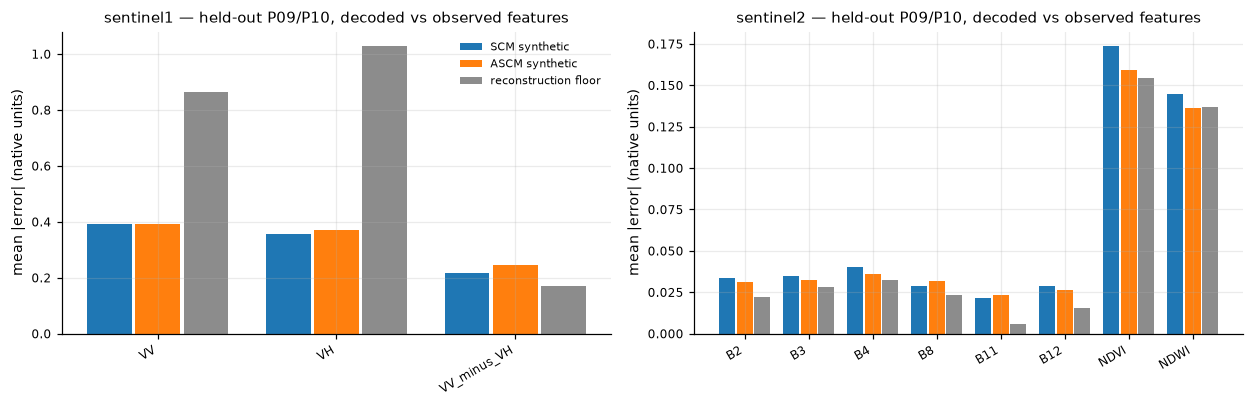

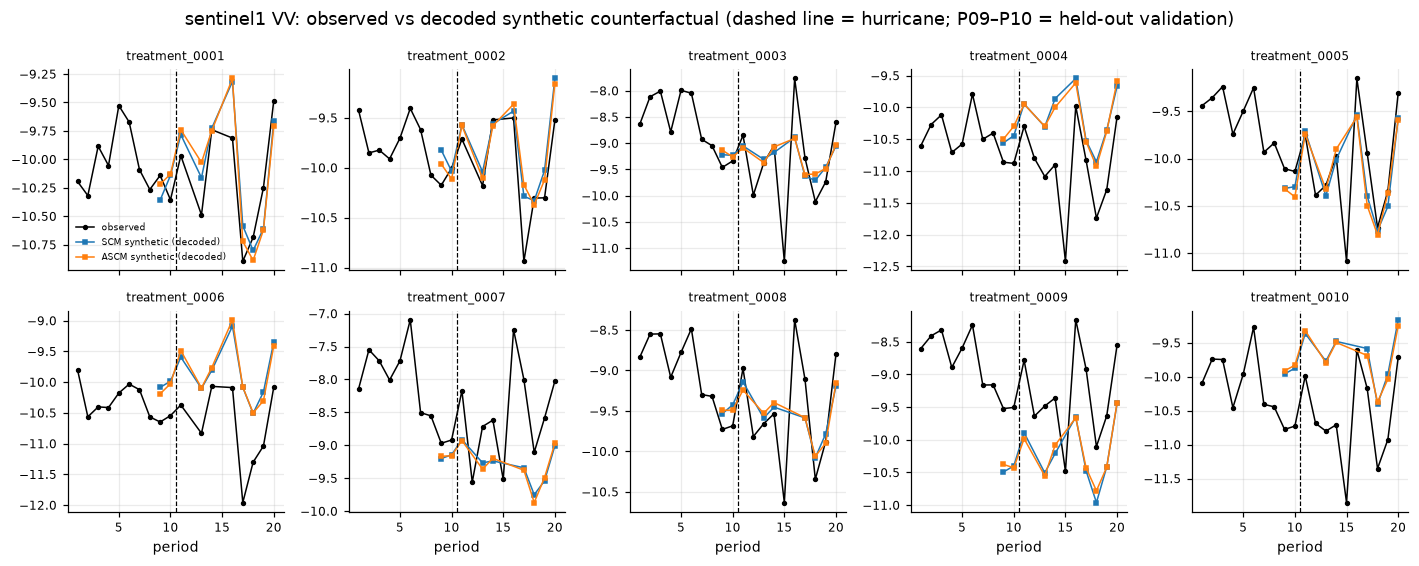

/tmp/ipykernel_2682003/838634701.py:100: RuntimeWarning: Mean of empty slice
  return {b: float(np.nanmean(chip[..., i])) for i, b in enumerate(BANDS[sensor])}


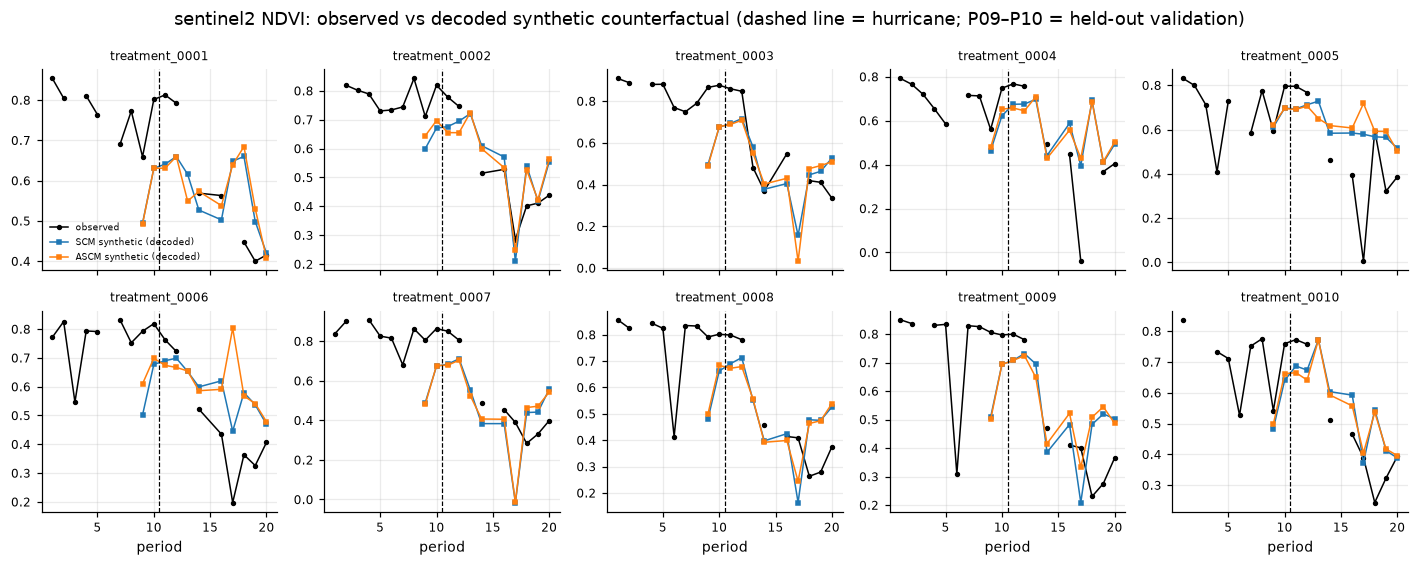

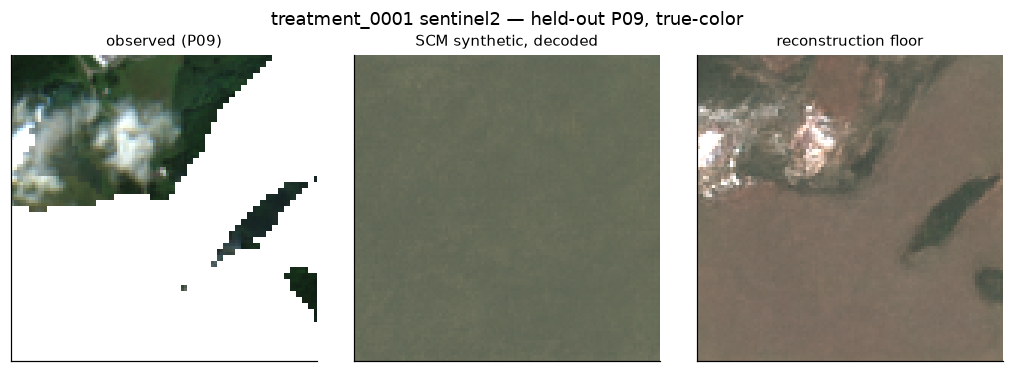

figures saved


In [6]:
# validation vs floor, feature space
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
for ax, sensor in zip(axes, SENSORS):
    bands = BANDS[sensor]; x = np.arange(len(bands))
    sub = (dv.query("space == 'feature' and sensor == @sensor")
           .assign(a=lambda t: t["value"].abs())
           .pivot_table(index="band", columns="method", values="a")
           .loc[bands])
    ax.bar(x - 0.27, sub["scm"], 0.25, label="SCM synthetic")
    ax.bar(x, sub["ascm"], 0.25, label="ASCM synthetic")
    ax.bar(x + 0.27, sub["floor"], 0.25, label="reconstruction floor", color="0.55")
    ax.set_xticks(x); ax.set_xticklabels(bands, rotation=30, ha="right")
    ax.set_title(f"{sensor} — held-out P09/P10, decoded vs observed features")
    ax.set_ylabel("mean |error| (native units)")
axes[0].legend(frameon=False, fontsize=7)
fig.tight_layout()
fig.savefig(TS / "panel_decode_validation_features.png", bbox_inches="tight")
plt.show()

# per-site trajectories: one key band per sensor
key_band = {"sentinel1": "VV", "sentinel2": "NDVI"}
for sensor in SENSORS:
    b = key_band[sensor]
    fig, axes = plt.subplots(2, 5, figsize=(13, 5.2), sharex=True)
    for ax, tid in zip(axes.ravel(), treatments):
        xs, obs = [], []
        for seq in range(1, 21):
            if have(tid, sensor, seq):
                f = feats_from_raw(
                    sensor, read_chip_biweekly(tif_path(tid, sensor, seq), sensor))
                xs.append(seq); obs.append(f[b])
        ax.plot(xs, obs, color="k", marker="o", ms=2.5, lw=1.0, label="observed")
        for method, color in (("scm", "C0"), ("ascm", "C1")):
            xs2 = [s for s in range(9, 21)
                   if dec_of.get((method, sensor, tid, s)) is not None]
            ys2 = [feats_from_decoded(sensor, dec_of[(method, sensor, tid, s)])[b]
                   for s in xs2]
            ax.plot(xs2, ys2, color=color, marker="s", ms=2.5, lw=1.0,
                    label=f"{method.upper()} synthetic (decoded)")
        ax.axvline(10.5, color="k", lw=0.8, ls="--")
        ax.set_title(tid, fontsize=8)
    axes[0, 0].legend(frameon=False, fontsize=6)
    for ax in axes[1]:
        ax.set_xlabel("period")
    fig.suptitle(f"{sensor} {b}: observed vs decoded synthetic counterfactual "
                 "(dashed line = hurricane; P09–P10 = held-out validation)")
    fig.tight_layout()
    fig.savefig(TS / f"panel_trajectories_{sensor}_{b}.png", bbox_inches="tight")
    plt.show()

# one example strip: observed vs SCM synthetic vs floor (S2 true color, P09)
tid = "treatment_0001"; sensor = "sentinel2"; seq = 9
chip = read_chip_biweekly(tif_path(tid, sensor, seq), sensor)
def rgb_native(c):   # (H,W,C) B2,B3,B4 -> display RGB
    r = np.stack([c[..., 2], c[..., 1], c[..., 0]], axis=-1)
    return np.clip(r / 0.30, 0, 1)
def rgb_decoded(d):
    nb_ = native_bands(sensor, d)
    r = np.stack([nb_[2], nb_[1], nb_[0]], axis=-1)
    return np.clip(r / 0.30, 0, 1)
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.4))
axes[0].imshow(rgb_native(chip)); axes[0].set_title("observed (P09)")
axes[1].imshow(rgb_decoded(dec_of[("scm", sensor, tid, seq)]))
axes[1].set_title("SCM synthetic, decoded")
axes[2].imshow(rgb_decoded(dec_of[("floor", sensor, tid, seq)]))
axes[2].set_title("reconstruction floor")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle(f"{tid} {sensor} — held-out P09, true-color")
fig.tight_layout()
fig.savefig(TS / "panel_decode_example.png", bbox_inches="tight")
plt.show()
print("figures saved")

## Reading

**Feature space (the pipeline's working units), P09/P10 held-out, next to the
reconstruction floor:**

- **S2 vegetation indices are decoder-limited, not donor-limited**: NDVI synthetic
  |error| 0.17 vs floor 0.15; NDWI 0.145 vs 0.137. Even a *perfect* counterfactual
  latent would do essentially no better — the encode→decode round trip already loses
  that much. The reflectance bands have more donor-attributable error (synthetic
  1.1–3.6× floor, e.g. B11 0.021 vs 0.006).
- **S1 chip means: the synthetic BEATS the floor** (VV 0.39 dB vs 0.87; VH 0.36 vs
  1.03). The floor is a per-pixel concept, not a bound for chip means: reconstructing
  one observed image carries a systematic per-image offset (the decoder bias already
  seen in the 26-site work), while decoding an *averaged* latent lands near the
  cross-site mean — which is close in chip means. Read this as: S1 chip-mean levels are
  easy; it says nothing about spatial fidelity.
- **Image space (per pixel)** behaves as theory says: floor below synthetic everywhere,
  and both are large (VV floor 2.4 dB RMSE per pixel, synthetic 3.2; S2 NDVI floor 0.18,
  synthetic 0.22). Pixel-level counterfactual imagery from this decoder is not usable
  for quantitative work; chip-level features are the honest readout.

**Effects (P11–P20, decoded features, SCM):** mean across sites × periods — NDVI −0.037
(SD 0.157), NDWI −0.041 (0.144), B8 −0.040 (0.048): the vegetation-loss direction.
S1: VH +0.26 dB (0.91), VV −0.03 (0.69). **Caution:** the P09/P10 validation errors are
the same size as these effects (NDVI error 0.17 vs effect −0.037), so *per-site,
per-period* effects are below the noise level; only the cross-site mean direction
carries information, and P12/P15 are missing for a third of sites.

**What this experiment shows:** with 5 embedding-kNN donors on the biweekly panel,
(1) weights fitted in latent space have no held-out predictive power — the latent is
site-specific; (2) ASCM cannot rescue that; (3) after decoding, the synthetic
counterfactual's usable accuracy is set mostly by the decoder floor (S2 indices) or by
the flatness of chip means (S1); (4) the feature-based pipeline's own validation
(notebook 14: 0.18–0.78 SD) passes the test this pipeline fails. If the tokenizer arm
is to stay competitive for *this* panel design, the candidates are: fit weights on
decoded features (not raw latents), reduce the latent (e.g. pool spatial positions)
before weighting, or use larger donor pools — each is a design decision to take to Jun
and the advisors, not a default.